# Caltech Learning From Data - HW 5

Họ và tên: Phan Bá Đức

MSSV: 22120071

## Linear Regression Error

### Question 1

Ta có công thức lỗi kỳ vọng trong mẫu được cho bởi:
$$ E_D[E_{in}(w_{lin})] = \sigma^2 \left(1 - \frac{d + 1}{N}\right) $$

Với:
- $\sigma = 0.1$, nên $\sigma^2 = (0.1)^2 = 0.01$
- $d = 8$, nên $d + 1 = 9$
- $N$ là số lượng mẫu huấn luyện cần tìm


Ta có
$$ 0.01 \left(1 - \frac{9}{N}\right) > 0.008 $$

$$ 1 - \frac{9}{N} > \frac{0.008}{0.01} $$

$$ 1 - \frac{9}{N} > 0.8 $$


$$ 1 - 0.8 > \frac{9}{N} $$

$$ 0.2 > \frac{9}{N} $$

Vì $N > 0$ nên:
$$ 0.2N > 9 $$

$$ N > \frac{9}{0.2} $$

$$ N > 45 $$

**Vậy kết quả thỏa N nhỏ nhất mà $ N > 45 $ là [c] 100**

## Nonlinear Transforms

### Question 2

Bài toán yêu cầu xác định ràng buộc trên trọng số $ \tilde{w}_1, \tilde{w}_2 $ trong không gian $ \mathcal{Z} $ với biến đổi $ \Phi(1, x_1, x_2) = (1, x_1^2, x_2^2) $, sao cho ranh giới quyết định trong $ \mathcal{X} $ là hyperbol mở theo trục $ x_2 $, giao $ x_1 $ tại $ \pm 1 $.

Phương trình ranh giới: 
$$ \tilde{w}_0 + \tilde{w}_1 x_1^2 + \tilde{w}_2 x_2^2 = 0 $$
Rút gọn thành 
$$ \tilde{w}_1 x_1^2 + \tilde{w}_2 x_2^2 = -\tilde{w}_0 $$
Suy ra
$$
-\frac{\tilde{w}_1}{\tilde{w}_0} x_1^2 - \frac{\tilde{w}_2}{\tilde{w}_0} x_2^2 = 1
$$

Công thức chính tắc của phường trình hyperbol la 
$$ \frac{(x_1)^2}{a^2} - \frac{(x_2)^2}{b^2} = 1 $$

Từ đồ thị phương trình, ta thấy hyperbol mở rộng theo chiều ngang nên
- $ -\frac{\tilde{w}_1}{\tilde{w}_0} > 0 $ (hệ số $ x_1^2 $ dương).
- $ -\frac{\tilde{w}_2}{\tilde{w}_0} < 0 $ (hệ số $ x_2^2 $ âm).

#### Xét hai trường hợp $ \tilde{w}_0 $:
- **$ \tilde{w}_0 > 0 $**: 
  - $ -\tilde{w}_1 > 0 \implies \tilde{w}_1 < 0 $.
  - $ -\tilde{w}_2 < 0 \implies \tilde{w}_2 > 0 $.
  - Tại $ x_1 = \pm 1, x_2 = 0 $: $ \tilde{w}_0 = -\tilde{w}_1 > 0 $, khớp. Gốc $ h(0,0) = \tilde{w}_0 > 0 $ (vùng $ +1 $), bên trong $ \tilde{w}_1 x_1^2 < 0 $ (vùng $ -1 $), phù hợp hình vẽ.
- **$ \tilde{w}_0 < 0 $**:
  - $ -\tilde{w}_1 < 0 \implies \tilde{w}_1 > 0 $.
  - $ -\tilde{w}_2 > 0 \implies \tilde{w}_2 < 0 $.
  - Gốc $ h(0,0) = \tilde{w}_0 < 0 $ (vùng $ -1 $), không khớp.

#### Kết luận:
Ràng buộc $ \tilde{w}_1 < 0, \tilde{w}_2 > 0 $ (với $ \tilde{w}_0 > 0 $) tạo hyperbol phù hợp với hình vẽ.

**Đáp án:** [d] $ \tilde{w}_1 < 0, \tilde{w}_2 > 0 $

### Question 3

VC dimension của mô hình tuyến tính trong không gian $d-chiều$ (**bao gồm hệ số tự do**) là d.

Ở đây, không gian biến đổi có 15 chiều (vì có 15 thành phần trong $ \phi_4$).

Do đó, VC dimension của mô hình tuyến tính trong không gian này là 15.

Vì vậy giá trị nhỏ nhất không nhỏ hơn VC dimension của mô hình tuyến tính này là 15.

**Đáp án: [c] 15**

## Gradient Descent

### Question 4

**Đặt $ f(u, v) = ue^v - 2ve^{-u} $**. Khi đó, $ E(u, v) = [f(u, v)]^2 $.

   $$
   \frac{\partial E}{\partial u} = 2f(u, v) \cdot \frac{\partial f}{\partial u}
   $$

Mà
   $$
   \frac{\partial f}{\partial u} = e^v + 2ve^{-u}
   $$

Thay vào công thức đạo hàm:
   $$
   \frac{\partial E}{\partial u} = 2(ue^v - 2ve^{-u})(e^v + 2ve^{-u})
   $$

**Đáp án: [E]  $2(e^v + 2ve^{-u})(ue^v - 2ve^{-u})$**

In [1]:
import numpy as np

def E(x):
    u = x[0]
    v = x[1]
    return (u * np.exp(v) - 2 * v * np.exp(-u)) ** 2

def dE(x):
    u = x[0]
    v = x[1]
    dE_du = 2 * (u * np.exp(v) - 2 * v * np.exp(-u)) * (np.exp(v) + 2 * v * np.exp(-u))
    dE_dv = 2 * (u * np.exp(v) - 2 * v * np.exp(-u)) * (u * np.exp(v) - 2 * np.exp(-u))
    return np.array([dE_du, dE_dv])

def GD(x, error, learning_rate=0.1):
    """
    Gradient Descent algorithm to minimize the function E(x).
    
    Parameters:
    x (np.ndarray): Initial guess for the variables [u, v].
    err (float): Error tolerance for convergence.
    learning_rate (float): Step size for the gradient descent.
    
    Returns:
    np.ndarray: The point where E(x) is minimized.
    """
    iterations = 0
    max_iterations = 1000
    while True:
        iterations += 1
        if iterations >= max_iterations:
            print("Warning: Maximum iterations reached.")
            return None
        
        grad = dE(x)
        x = x - learning_rate * grad
        err = E(x)
        if err < error:
            break
        
    return x, err, iterations

x0 = np.array([1.0, 1.0])
error = 1e-14
result, err, iterations = GD(x0, error)

print(f"Result: {result}")
print(f"Error: {err}")
print(f"Iterations: {iterations}")


Result: [0.04473629 0.02395871]
Error: 1.2086833944220747e-15
Iterations: 10


### Question 5

Dựa vào kết quả trả ra, **đáp án là [d] 10**

### Question 6

Dựa vào kết quả trả ra, **đáp án là  [e] (0.045, 0.024)**

In [2]:
import numpy as np

def E(x):
    u = x[0]
    v = x[1]
    return (u * np.exp(v) - 2 * v * np.exp(-u)) ** 2

def dE_u(x):
    u = x[0]
    v = x[1]
    return 2 * (u * np.exp(v) - 2 * v * np.exp(-u)) * (np.exp(v) + 2 * v * np.exp(-u))


def dE_v(x):
    u = x[0]
    v = x[1]
    return 2 * (u * np.exp(v) - 2 * v * np.exp(-u)) * (u * np.exp(v) - 2 * np.exp(-u))
   

def coordinateGD(max_iteration ,x, learning_rate=0.1):
    u = x[0]
    v = x[1]
    for i in range(max_iteration):
        u = u - learning_rate * dE_u((u, v)) 
        v = v - learning_rate * dE_v((u, v))  # Truyền (u, v) thay vì x. Vì dE_v cần cả u (sau khi biến đổi ) và v
    return E([u, v])

x0 = np.array([1.0, 1.0])

err = coordinateGD(15, x0)

print(f"Error: {err}")



Error: 0.13981379199615315


### Question 7

Dựa vào kết quả trả ra, **đáp án là [a] $10^{-1}$**

##  Logistic Regression

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def generate_target_w():
    """
    Generates target_w from two random, uniformly distributed points in [-1, 1] x [-1, 1].
    
    Returns
    -------
    target_w : numpy array, shape (3, 1) 
        The vector of parameters of f.
    """
    # Generate two points from a uniform distribution over [-1, 1]x[-1, 1]
    p1 = np.random.uniform(-1, 1, 2)
    p2 = np.random.uniform(-1, 1, 2)
    # Compute the target W from these two points
    target_w = np.array([p1[1] * p2[0] - p1[0] * p2[1], p2[1] - p1[1], p1[0] - p2[0]]).reshape((-1, 1))
    
    return target_w

In [5]:
def generate_data(N, target_w):
    """
    Generates a data set by generating random inputs and then using target_w to generate the 
    corresponding outputs.
    
    Parameters
    ----------
    N : int
        The number of examples.
    target_w : numpy array, shape (3, 1) 
        The vector of parameters of f.
    
    Returns
    -------
    X : numpy array, shape (N, 3)
        The matrix of input vectors (each row corresponds to an input vector); the first column of 
        this matrix is all ones.
    Y : numpy array, shape (N, 1)
        The vector of outputs.        
    """
    X = np.random.uniform(-1, 1, (N, 2))
    X = np.hstack((np.ones((N, 1)), X)) # Add 'ones' column
    Y = np.sign(np.dot(X, target_w))
    
    return X, Y

Trực quan hóa thử dữ liệu tạo ra

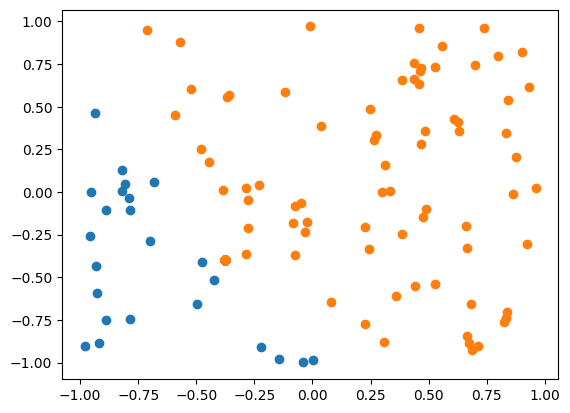

In [6]:
# Generate target_w
target_w = generate_target_w()

# Generate training set
X, Y = generate_data(100, target_w)

ibelow = np.where(Y==-1)
iabove = np.where(Y==1)


plt.scatter(X[ibelow,1], X[ibelow,2])
plt.scatter(X[iabove,1], X[iabove,2])
plt.show()


In [7]:
def sigmoid(x):
    """
    Computes the sigmoid function.
    
    Parameters
    ----------
    x : numpy array
        The input to the sigmoid function.
    
    Returns
    -------
    numpy array
        The output of the sigmoid function.
    """
    return 1 / (1 + np.exp(-x))

class LogisticRegression:
    """
    Logistic regression classifier.
    
    Parameters
    ----------
    learning_rate : float
        The learning rate for gradient descent.
    max_iter : int
        The maximum number of iterations for gradient descent.
    """
    def __init__(self, learning_rate=0.01, max_iter=1000):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.w = None
    
    def fit(self, X, Y):
        """
        Fits the logistic regression model to the training data.
        
        Parameters
        ----------
        X : numpy array, shape (N, 3)
            The matrix of input vectors (each row corresponds to an input vector); the first column of 
            this matrix is all ones.
        Y : numpy array, shape (N, 1)
            The vector of outputs.        
        """
        N, d = X.shape
        self.w = np.zeros((d, 1))
        epoch = 0

        while True:
            pre_w = np.copy(self.w)
            epoch += 1

            mix_index = np.random.permutation(N)
            for i in mix_index:
                x_i = X[i].reshape(-1, 1)
                y_i = 1 if Y[i] == 1 else 0  # Chuyển Y thành {0, 1}
                y_hat = sigmoid(np.dot(self.w.T, x_i))
                self.w += self.learning_rate * (y_i - y_hat) * x_i

            if np.linalg.norm(pre_w - self.w) < 0.01:  # Sửa lỗi
                break
        return epoch
    
    def predict(self, X):
        """
        Predicts the output for the given input data.
        
        Parameters
        ----------
        X : numpy array, shape (N, 3)
            The matrix of input vectors (each row corresponds to an input vector); the first column of 
            this matrix is all ones.
        
        Returns
        -------
        numpy array
            The predicted outputs.
        """
        prob = sigmoid(np.dot(X, self.w))
        return np.where(prob >= 0.5, 1, -1)
    
    def cross_entropy_error(self, X, Y):
        """
        Computes the cross-entropy error.
        
        Parameters
        ----------
        X : numpy array, shape (N, 3)
            The matrix of input vectors (each row corresponds to an input vector); the first column of 
            this matrix is all ones.
        Y : numpy array, shape (N, 1)
            The vector of outputs.        
        
        Returns
        -------
        float
            The cross-entropy error.
        """
        N = X.shape[0]
        y_hat = sigmoid(np.dot(X, self.w))
        Y_binary = np.where(Y == 1, 1, 0)
        return -np.sum(Y_binary * np.log(y_hat + 1e-15) + (1 - Y_binary) * np.log(1 - y_hat + 1e-15)) / N

In [8]:
error = []
epoches = []
for i in range(100):
    target_w = generate_target_w()
    X, Y = generate_data(100, target_w)
    model = LogisticRegression(learning_rate=0.01, max_iter=1000)
    epoch = model.fit(X, Y)

    X_test, Y_test = generate_data(1000, target_w)
    Y_pred = model.predict(X_test)
    
    epoches.append(epoch)
    error.append(model.cross_entropy_error(X_test, Y_test))

print("Average error: ", np.mean(error)) 
print("Average epochs: ", np.mean(epoches))

Average error:  0.10252888284038725
Average epochs:  345.8


### Question 8

Dựa vào kết quả trả ra, **đáp án gần nhất là [d] 0.100**

### Question 9

Dựa vào kết quả trả ra, **đáp án gần nhất là [a] 350**

## PLA as SGD

### Question 10

- Quy tắc cập nhật của Perceptron: Nếu một điểm dự đoán đúng thì để nguyên trọng số, còn nếu một điểm bị phân loại sai (tức là $ y_n \mathbf{w}^T \mathbf{x}_n \leq 0 $), thì cập nhật trọng số:

  $$
  \mathbf{w} \gets \mathbf{w} + \eta y_n \mathbf{x}_n
  $$

  với $\eta$ là tốc độ học (thường chọn $\eta = 1$).

- Khi triển khai Perceptron dưới dạng SGD, ta cần một hàm lỗi $ e_n(\mathbf{w}) $ sao cho gradient của nó dẫn đến quy tắc cập nhật trên. Cụ thể, SGD cập nhật trọng số theo hướng ngược gradient:
  
  $$
  \mathbf{w} \gets \mathbf{w} - \eta \nabla e_n(\mathbf{w})
  $$

  Để khớp với Perceptron, ta cần $\nabla e_n(\mathbf{w}) = -y_n \mathbf{x}_n$ khi dự đoán sai và $\nabla e_n(\mathbf{w}) = 0$ khi dự đoán đúng.

**Phân tích từng đáp án**

1. **a) $ e_n(\mathbf{w}) = e^{-y_n \mathbf{w}^T \mathbf{x}_n} $**:

   - Gradient:
  
     $$
     \nabla e_n = -y_n \mathbf{x}_n e^{-y_n \mathbf{w}^T \mathbf{x}_n}
     $$

   - Khi dự đoán sai ($ y_n \mathbf{w}^T \mathbf{x}_n \leq 0 $), $ e^{-y_n \mathbf{w}^T \mathbf{x}_n} \geq 1 $, gradient có dạng $ -y_n \mathbf{x}_n \cdot \text{một số dương} $.
  
   - Khi dự đoán đúng ($ y_n \mathbf{w}^T \mathbf{x}_n > 0 $), $ e^{-y_n \mathbf{w}^T \mathbf{x}_n} < 1 $, nhưng gradient vẫn khác 0, không phù hợp với Perceptron (vì không cập nhật khi dự đoán đúng).\

2. **b) $ e_n(\mathbf{w}) = -y_n \mathbf{w}^T \mathbf{x}_n $**:
   
    - Gradient:
  
     $$
     \nabla e_n = \frac{\partial}{\partial \mathbf{w}} (-y_n \mathbf{w}^T \mathbf{x}_n) = -y_n \mathbf{x}_n
     $$

    - Cập nhật trong SGD: $\mathbf{w} \gets \mathbf{w} - \eta \nabla e_n = \mathbf{w} + \eta y_n \mathbf{x}_n$.

    - Gradient này **luôn khác 0**, bất kể dự đoán đúng hay sai. => không phù hợp với Perceptron

3. **c) $ e_n(\mathbf{w}) = (y_n - \mathbf{w}^T \mathbf{x}_n)^2 $**:
  
  - Gradient:
  
     $$
     \nabla e_n = -2 (y_n - \mathbf{w}^T \mathbf{x}_n) \mathbf{x}_n
     $$

  - Gradient này phụ thuộc vào giá trị $ y_n - \mathbf{w}^T \mathbf{x}_n $, không phải dạng $ -y_n \mathbf{x}_n $, và luôn khác 0 (trừ khi $ \mathbf{w}^T \mathbf{x}_n = y_n $), nên cũng không phù hợp.

4. **d) $ e_n(\mathbf{w}) = \ln(1 + e^{-y_n \mathbf{w}^T \mathbf{x}_n}) $**:
   
  - Gradient:

     $$
     \nabla e_n = -\frac{y_n \mathbf{x}_n}{1 + e^{y_n \mathbf{w}^T \mathbf{x}_n}}
     $$

  - Gradient này là dạng của hồi quy logistic, không phù hợp với Perceptron vì nó luôn khác 0, ngay cả khi dự đoán đúng.

5. **e) $ e_n(\mathbf{w}) = -\min(0, y_n \mathbf{w}^T \mathbf{x}_n) $**:
   
   - Hàm này có thể viết lại:
     - Nếu $ y_n \mathbf{w}^T \mathbf{x}_n \leq 0 $, thì $ e_n = -y_n \mathbf{w}^T \mathbf{x}_n $.
     - Nếu $ y_n \mathbf{w}^T \mathbf{x}_n > 0 $, thì $ e_n = 0 $.
  
   - Gradient:
     - Khi dự đoán sai ($ y_n \mathbf{w}^T \mathbf{x}_n \leq 0 $), $ e_n = -y_n \mathbf{w}^T \mathbf{x}_n $, nên:
       $$
       \nabla e_n = -y_n \mathbf{x}_n
       $$
       
     - Khi dự đoán đúng ($ y_n \mathbf{w}^T \mathbf{x}_n > 0 $), $ e_n = 0 $, nên:
       $$
       \nabla e_n = 0
       $$
    => Khớp với perceptron

**Vậy đáp án là [e] $ e_n(\mathbf{w}) = -\min(0, y_n \mathbf{w}^T \mathbf{x}_n) $**